In [28]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
from mord import LogisticAT
from scipy.linalg import toeplitz
from scipy.spatial.distance import jensenshannon
from scipy.special import rel_entr

In [2]:
def distributional_qwk(P: np.ndarray, Q: np.ndarray) -> float:
    """
    Compute QWK between two sets of score distributions.

    Args:
        P: (n_essays, n_scores) array of score distributions from rater 1
        Q: (n_essays, n_scores) array of score distributions from rater 2

    Returns:
        Quadratically weighted kappa.
    """
    n_essays, n_scores = P.shape

    # Quadratic weight matrix
    scores = np.arange(n_scores)
    W = (scores[:, None] - scores[None, :]) ** 2 / (n_scores - 1) ** 2

    # Observed matrix: average outer product across essays
    O = np.einsum("ki,kj->ij", P, Q) / n_essays

    # Expected matrix: outer product of marginals
    p_marginal = P.mean(axis=0)
    q_marginal = Q.mean(axis=0)
    E = np.outer(p_marginal, q_marginal)

    return 1 - (W * O).sum() / (W * E).sum()

In [3]:
# Distances

def jeffreys_dist(p: np.ndarray, q: np.ndarray) -> float:
    return float(np.sum(rel_entr(p, q)) + np.sum(rel_entr(q, p)))


def jensen_shannon_dist(p: np.ndarray, q: np.ndarray) -> float:
    js_sqrt = jensenshannon(p, q, base=2)
    if np.isnan(js_sqrt):
        return 0
    return np.clip(jensenshannon(p, q, base=2) ** 2, 0, 1)


def total_variation_dist(p: np.ndarray, q: np.ndarray) -> float:
    return float(np.linalg.norm(p - q, 1) / 2)

In [4]:
# Load test data set
df_test = pd.read_csv("data/data_test.zip")
df_test

,full_text,holistic_essay_score,embeddings_1024,embeddings_512
0,Technology has advanced tremendously in the pa...,5,"[0.030847841873764992, -0.02644442394375801, -...","[0.04308844357728958, -0.03693772479891777, -0..."
1,"I disagree with online classes because, if sch...",3,"[-0.028968339785933495, -0.030072828754782677,...","[-0.04022398963570595, -0.041757624596357346, ..."
2,I believe that students would benefit from bei...,5,"[-0.005486608482897282, -0.015514797531068325,...","[-0.007884071208536625, -0.022294240072369576,..."
3,"Kevin Sirmont, a famous professor at the Unive...",6,"[-0.007180897518992424, 0.01365605928003788, -...","[-0.01020435057580471, 0.019405821338295937, -..."
4,What is your verdict on students no going to s...,4,"[0.0003415282699279487, 0.011052927933633327, ...","[0.0004880860506091267, 0.01579599827528, -0.0..."
...,...,...,...,...
654,Some schools offer classes at home with online...,4,"[-0.035018738359212875, -0.04749249666929245, ...","[-0.04921531677246094, -0.06674592941999435, -..."
655,I agreed studient should being able to attend ...,4,"[0.023513805121183395, -0.018654851242899895, ...","[0.03293759748339653, -0.02613128535449505, -0..."
656,Students that take classes from home is way ea...,3,"[0.004808255936950445, -0.03937520086765289, -...","[0.006538220215588808, -0.05354201793670654, -..."
657,I had classes at home and i did just fine. Whe...,3,"[-0.017591169103980064, 0.0026313529815524817,...","[-0.024740979075431824, 0.003700848435983062, ..."


In [5]:
embedding_matrix_test_512 = np.array([eval(embedding) for embedding in df_test["embeddings_512"]])
embedding_matrix_test_1024 = np.array([eval(embedding) for embedding in df_test["embeddings_1024"]])

In [6]:
C = toeplitz(np.arange(0, 6) ** 2)

In [7]:
model_reference_params = np.load("data/model_reference.npz")
model_unconstrained_params = np.load("data/model_unconstrained.npz")
model_constrained_tv_params = np.load("data/model_constrained_tv.npz")
model_constrained_jf_params = np.load("data/model_constrained_jf.npz")
model_constrained_js_params = np.load("data/model_constrained_js.npz")

In [8]:
model_reference = LogisticAT(alpha=5e-3)
model_reference.theta_ = model_reference_params["theta"]
model_reference.coef_ = model_reference_params["coef"]

In [9]:
model_unconstrained = LogisticAT(alpha=5e-3)
model_unconstrained.theta_ = model_unconstrained_params["theta"]
model_unconstrained.coef_ = model_unconstrained_params["coef"]

In [10]:
model_constrained_tv = LogisticAT(alpha=5e-3)
model_constrained_tv.theta_ = model_constrained_tv_params["theta"]
model_constrained_tv.coef_ = model_constrained_tv_params["coef"]

In [11]:
model_constrained_jf = LogisticAT(alpha=5e-3)
model_constrained_jf.theta_ = model_constrained_jf_params["theta"]
model_constrained_jf.coef_ = model_constrained_jf_params["coef"]

In [12]:
model_constrained_js = LogisticAT(alpha=5e-3)
model_constrained_js.theta_ = model_constrained_js_params["theta"]
model_constrained_js.coef_ = model_constrained_js_params["coef"]

In [13]:
P_test_reference = model_reference.predict_proba(embedding_matrix_test_1024)
P_test_unconstrained = model_unconstrained.predict_proba(embedding_matrix_test_512)
P_test_constrained_tv = model_constrained_tv.predict_proba(embedding_matrix_test_512)
P_test_constrained_jf = model_constrained_jf.predict_proba(embedding_matrix_test_512)
P_test_constrained_js = model_constrained_js.predict_proba(embedding_matrix_test_512)

In [14]:
mse_unconstrained = np.mean([p @ C @ q for p, q in zip(P_test_reference, P_test_unconstrained)])
mse_constrained_tv = np.mean([p @ C @ q for p, q in zip(P_test_reference, P_test_constrained_tv)])
mse_constrained_jf = np.mean([p @ C @ q for p, q in zip(P_test_reference, P_test_constrained_jf)])
mse_constrained_js = np.mean([p @ C @ q for p, q in zip(P_test_reference, P_test_constrained_js)])

In [15]:
qwk_unconstrained = distributional_qwk(P_test_reference, P_test_unconstrained)
qwk_constrained_tv = distributional_qwk(P_test_reference, P_test_constrained_tv)
qwk_constrained_jf = distributional_qwk(P_test_reference, P_test_constrained_jf)
qwk_constrained_js = distributional_qwk(P_test_reference, P_test_constrained_js)

In [16]:
df_accuracy = pd.DataFrame(
    {"MSE": [mse_unconstrained, mse_constrained_jf, mse_constrained_js, mse_constrained_tv], 
     "QWK": [qwk_unconstrained, qwk_constrained_jf, qwk_constrained_js, qwk_constrained_tv]},
    index=["Unconstrained", "Jeffreys", "Jensen-Shannon", "Total Variation"])

In [17]:
# Table 1
df_accuracy

,MSE,QWK
Unconstrained,0.554863,0.792763
Jeffreys,0.611455,0.738698
Jensen-Shannon,0.617263,0.749478
Total Variation,0.620594,0.756180


In [18]:
# Evaluate score distribution distances
N = P_test_reference.shape[0]

In [19]:
tv_reference = np.array([total_variation_dist(P_test_reference[i], P_test_reference[j]) for i in range(N) for j in range(i + 1, N)])
tv_unconstrained = np.array([total_variation_dist(P_test_unconstrained[i], P_test_unconstrained[j]) for i in range(N) for j in range(i + 1, N)])
tv_constrained = np.array([total_variation_dist(P_test_constrained_tv[i], P_test_constrained_tv[j]) for i in range(N) for j in range(i + 1, N)])

In [20]:
jf_reference = np.array([jeffreys_dist(P_test_reference[i], P_test_reference[j]) for i in range(N) for j in range(i + 1, N)])
jf_unconstrained = np.array([jeffreys_dist(P_test_unconstrained[i], P_test_unconstrained[j]) for i in range(N) for j in range(i + 1, N)])
jf_constrained = np.array([jeffreys_dist(P_test_constrained_jf[i], P_test_constrained_jf[j]) for i in range(N) for j in range(i + 1, N)])

In [21]:
js_reference = np.array([jensen_shannon_dist(P_test_reference[i], P_test_reference[j]) for i in range(N) for j in range(i + 1, N)])
js_unconstrained = np.array([jensen_shannon_dist(P_test_unconstrained[i], P_test_unconstrained[j]) for i in range(N) for j in range(i + 1, N)])
js_constrained = np.array([jensen_shannon_dist(P_test_constrained_js[i], P_test_constrained_js[j]) for i in range(N) for j in range(i + 1, N)])

/Users/mfauss/Projects/venvs/venv_3.14/lib/python3.14/site-packages/scipy/spatial/distance.py:1290: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(js / 2.0)


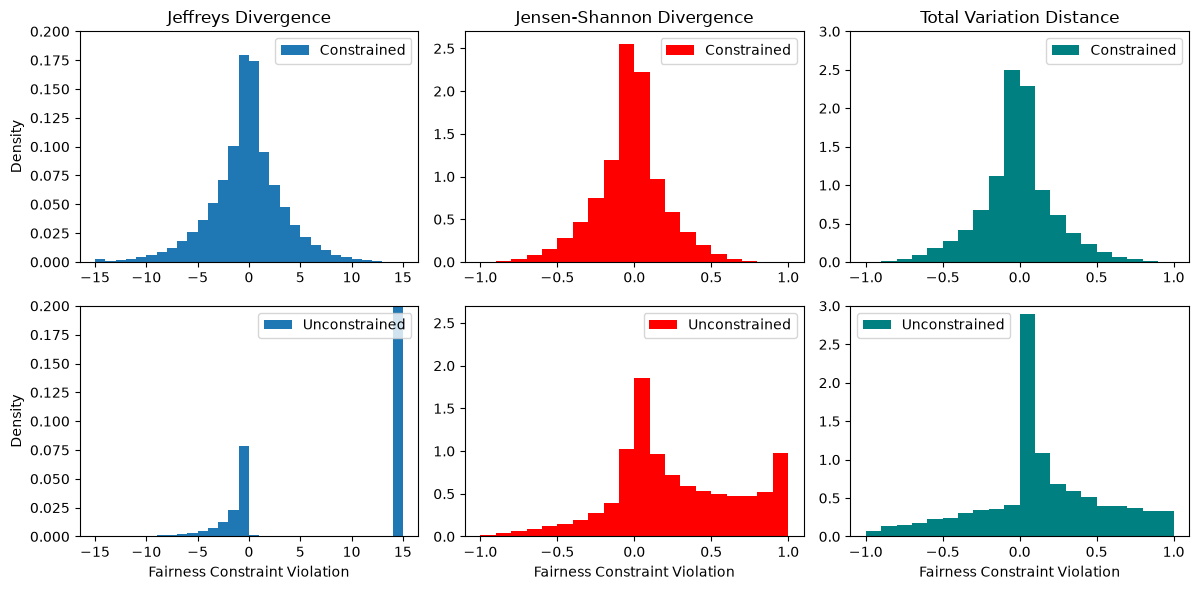

In [22]:
# Figure 1
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

axes[0, 0].hist(np.clip(jf_constrained - jf_reference, -15, 15), density=True, bins=np.linspace(-15, 15, 31), label="Constrained")
axes[0, 0].set_ylim([0, 0.2])
axes[0, 0].set_title("Jeffreys Divergence")
axes[0, 0].set_ylabel("Density")
axes[1, 0].hist(np.clip(jf_unconstrained - jf_reference, -15, 15), density=True, bins=np.linspace(-15, 15, 31), label="Unconstrained")
axes[1, 0].set_ylim([0, 0.2])
axes[1, 0].set_xlabel("Fairness Constraint Violation")
axes[1, 0].set_ylabel("Density")

axes[0, 1].hist(js_constrained - js_reference, density=True, bins=np.linspace(-1, 1, 21), color="red", label="Constrained")
axes[0, 1].set_title("Jensen-Shannon Divergence")
axes[0, 1].set_ylim([0, 2.7])
axes[1, 1].hist(js_unconstrained - js_reference, density=True, bins=np.linspace(-1, 1, 21), color="red", label="Unconstrained")
axes[1, 1].set_ylim([0, 2.7])
axes[1, 1].set_xlabel("Fairness Constraint Violation")

axes[0, 2].hist(tv_constrained - tv_reference, density=True, bins=np.linspace(-1, 1, 21), color="teal", label="Constrained")
axes[0, 2].set_title("Total Variation Distance")
axes[0, 2].set_ylim([0, 3])
axes[1, 2].hist(tv_unconstrained - tv_reference, density=True, bins=np.linspace(-1, 1, 21), color="teal", label="Unconstrained")
axes[1, 2].set_ylim([0, 3])
axes[1, 2].set_xlabel("Fairness Constraint Violation")

for ax in axes.flatten():
    ax.legend(loc="upper right")

plt.tight_layout()
plt.legend()
plt.show()

In [23]:
# Share of constraint violations
df_share_of_constraint_violations = pd.DataFrame(
 {"Constrained": [np.mean(jf_constrained > jf_reference), np.mean(js_constrained > js_reference), np.mean(tv_constrained > tv_reference)],
  "Unocnstrained": [np.mean(jf_unconstrained > jf_reference), np.mean(js_unconstrained > js_reference), np.mean(tv_unconstrained > tv_reference)]},
    index=["Jeffreys", "Jensen-Shannon", "Total Variation"]
)
df_share_of_constraint_violations

,Constrained,Unocnstrained
Jeffreys,0.478043,0.863208
Jensen-Shannon,0.447989,0.762208
Total Variation,0.470013,0.759782


In [24]:
# Average constraint violation
df_share_of_constraint_violations = pd.DataFrame(
 {"Constrained": [np.mean(jf_constrained - jf_reference), np.mean(js_constrained - js_reference), np.mean(tv_constrained - tv_reference)],
  "Unocnstrained": [np.mean(jf_unconstrained - jf_reference), np.mean(js_unconstrained - js_reference), np.mean(tv_unconstrained - tv_reference)]},
    index=["Jeffreys", "Jensen-Shannon", "Total Variation"]
)
df_share_of_constraint_violations

,Constrained,Unocnstrained
Jeffreys,-0.245754,inf
Jensen-Shannon,-0.024736,0.264185
Total Variation,-0.013107,0.131375


In [25]:
# Average positive constraint violation
diff_jf_constrained = jf_constrained - jf_reference
diff_js_constrained = js_constrained - js_reference
diff_tv_constrained = tv_constrained - tv_reference

diff_jf_unconstrained = jf_unconstrained - jf_reference
diff_js_unconstrained = js_unconstrained - js_reference
diff_tv_unconstrained = tv_unconstrained - tv_reference

df_share_of_constraint_violations = pd.DataFrame(
 {"Constrained": [np.mean(diff_jf_constrained[diff_jf_constrained > 0]), np.mean(diff_js_constrained[diff_js_constrained > 0]), np.mean(diff_tv_constrained[diff_tv_constrained > 0])],
  "Unconstrained": [np.mean(diff_jf_unconstrained[diff_jf_unconstrained > 0]), np.mean(diff_js_unconstrained[diff_js_unconstrained > 0]), np.mean(diff_tv_unconstrained[diff_tv_unconstrained > 0])]},
    index=["Jeffreys", "Jensen-Shannon", "Total Variation"]
)
df_share_of_constraint_violations

,Constrained,Unconstrained
Jeffreys,2.351236,inf
Jensen-Shannon,0.149552,0.415348
Total Variation,0.161699,0.291691


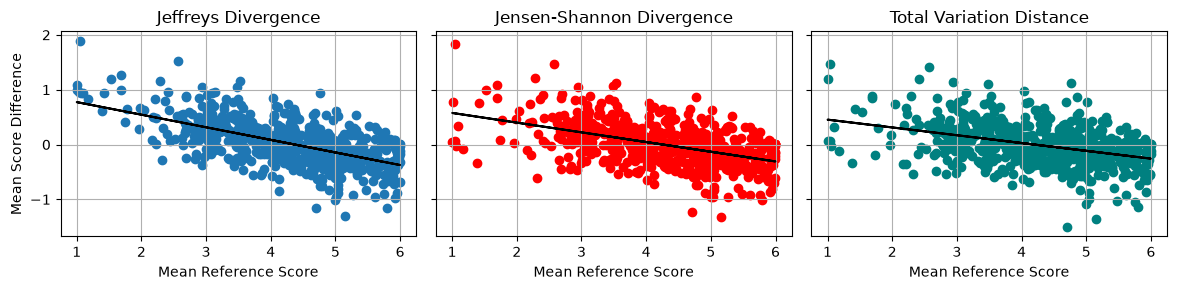

In [26]:
# Figure 2
mean_score_reference = P_test_reference @ np.arange(1, 7)
mean_score_jf = P_test_constrained_jf @ np.arange(1, 7)
mean_score_js = P_test_constrained_js @ np.arange(1, 7)
mean_score_tv = P_test_constrained_tv @ np.arange(1, 7)

# Linear regression
slope_jf, intercept_jf = np.polyfit(mean_score_reference, mean_score_jf - mean_score_reference, 1)
slope_js, intercept_js = np.polyfit(mean_score_reference, mean_score_js - mean_score_reference, 1)
slope_tv, intercept_tv = np.polyfit(mean_score_reference, mean_score_tv - mean_score_reference, 1)

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

axes[0].scatter(mean_score_reference, mean_score_jf - mean_score_reference)
axes[0].plot(mean_score_reference, slope_jf * mean_score_reference + intercept_jf, color="black")
axes[0].set_title("Jeffreys Divergence")
axes[0].set_xlabel("Mean Reference Score")
axes[0].set_ylabel("Mean Score Difference")
axes[0].grid()

axes[1].scatter(mean_score_reference, mean_score_js - mean_score_reference, color="red")
axes[1].plot(mean_score_reference, slope_js * mean_score_reference + intercept_js, color="black")
axes[1].set_title("Jensen-Shannon Divergence")
axes[1].set_xlabel("Mean Reference Score")
axes[1].grid()

axes[2].scatter(mean_score_reference, mean_score_tv - mean_score_reference, color="teal")
axes[2].plot(mean_score_reference, slope_tv * mean_score_reference + intercept_tv, color="black")
axes[2].set_title("Total Variation Distance")
axes[2].set_xlabel("Mean Reference Score")
axes[2].grid()

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Score Variance')

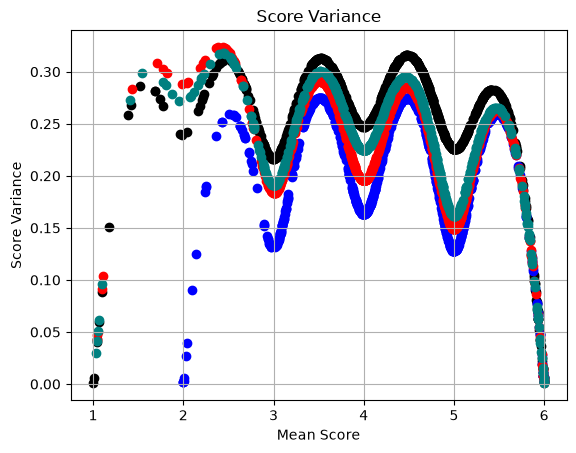

In [27]:
# Figure 3
var_score_reference = P_test_reference @ np.arange(1, 7) ** 2 - mean_score_reference ** 2
var_score_jf = P_test_constrained_jf @ np.arange(1, 7) ** 2 - mean_score_jf ** 2
var_score_js = P_test_constrained_js @ np.arange(1, 7) ** 2 - mean_score_js ** 2
var_score_tv = P_test_constrained_tv @ np.arange(1, 7) ** 2 - mean_score_tv ** 2

plt.scatter(mean_score_reference, var_score_reference, color="black", label="Reference")
plt.scatter(mean_score_jf, var_score_jf, color="blue", label="Jeffreys Divergence")
plt.scatter(mean_score_js, var_score_js, color="red", label="Jensen-Shannon Divergence")
plt.scatter(mean_score_tv, var_score_tv, color="teal", label="Total Variation Distance")

plt.title("Score Variance")
plt.grid()
plt.xlabel("Mean Score")
plt.ylabel("Score Variance")